# Minimal GRAPE with B-splines

This notebook is meant to be easy to read and tweak. The Hamiltonian, B-splines, decay operators, and optimizer loops are written directly here.

The only small helper file is `grape.py`, which contains repeated one-line operations: convert coefficients to envelopes, compute a Fock probability, add a tiny pulse penalty, and clip coefficients.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

cwd = Path.cwd()
project_dir = cwd if (cwd / "grape.py").exists() else cwd / "Simplified_adaptive_grape"
repo_root = project_dir.parent
sys.path.insert(0, str(project_dir))
sys.path.insert(0, str(repo_root))

import toolbox as tbx
import grape


/Users/nicol/coding/hybrid_residual_grape/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read the experimental values directly from `configuration.json`

The frequencies below are angular frequencies in `rad / us`. Since `1 MHz = 1 cycle / us`, the conversion is just `2*pi*MHz`; for a value in kHz we multiply by `1e-3` first.


In [2]:
config_path = repo_root / "configuration.json"
with config_path.open("r") as f:
    cfg = json.load(f)

# kHz -> MHz -> rad/us. We use a negative chi so H_disp = chi * n_cavity * |e><e|.
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
cavity_self_kerr = 2 * jnp.pi * cfg["self_Kerr_kHz"] * 1e-3

mu_qub = 20.0
mu_cav = 20.0

qubit_T1_us = float(cfg["qubit_T1_us"])
qubit_T2_us = float(cfg["qubit_T2_us"])
cavity_T1_us = float(cfg["storage_T1_us"])
cavity_T2_us = float(cfg["storage_T2_us"])

print("chi [rad/us] =", float(chi))
print("self-Kerr [rad/us] =", float(cavity_self_kerr))
print("T1/T2 qubit [us] =", qubit_T1_us, qubit_T2_us)
print("T1/T2 cavity [us] =", cavity_T1_us, cavity_T2_us)


chi [rad/us] = -4.145440537691808
self-Kerr [rad/us] = -0.0045308049250071996
T1/T2 qubit [us] = 43.5 32.5
T1/T2 cavity [us] = 226.2 334.6


## Pulse basis and simulation grid

We build `24` quadratic B-splines, skip the first two and last two, and therefore optimize `20` B-spline coefficients per real channel. There are four real channels: qubit I/Q and cavity I/Q.


B-splines on midpoints: (20, 130)
B-splines on edges: (20, 131)
endpoint max: 0.0
max active B-splines: 3


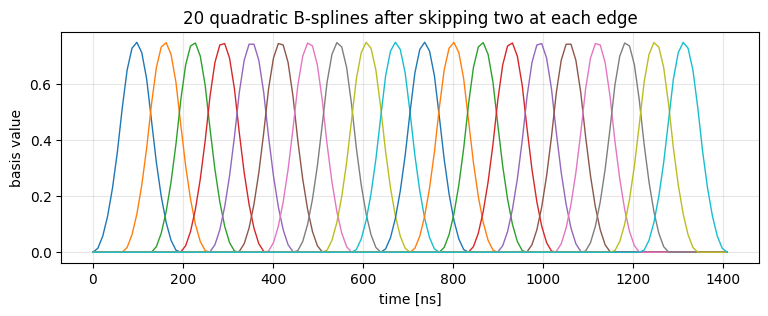

In [15]:
N_cav = 25
target_n = 2

param_clip = 2.0
n_channels = 4
n_total_bsplines = 24
spline_degree = 2
skip_left = 2
skip_right = 2
bspln_num = n_total_bsplines - skip_left - skip_right
assert bspln_num == 20

T_us = 1.408
Nt = 130

time_start = 0.0
time_end = T_us
time_edges = jnp.linspace(time_start, time_end, Nt + 1)
time_mids = 0.5 * (time_edges[1:] + time_edges[:-1])
time_intervals = time_edges[1:] - time_edges[:-1]

bspline_builder = tbx.setup_bspline_builder(
    time_start,
    time_end,
    n_total_bsplines,
    spline_degree,
    skip_left,
    skip_right,
)
bsplns_mids = jnp.asarray(bspline_builder(np.asarray(time_mids)))
bsplns_edges = jnp.asarray(bspline_builder(np.asarray(time_edges)))

print("B-splines on midpoints:", bsplns_mids.shape)
print("B-splines on edges:", bsplns_edges.shape)
print("endpoint max:", float(jnp.max(jnp.abs(bsplns_edges[:, [0, -1]]))))
print("max active B-splines:", int(jnp.max(jnp.sum(bsplns_mids > 1e-12, axis=0))))

plt.figure(figsize=(9, 3))
for b in np.asarray(bsplns_edges):
    plt.plot(np.asarray(time_edges) * 1e3, b, lw=1)
plt.xlabel("time [ns]")
plt.ylabel("basis value")
plt.title("20 quadratic B-splines after skipping two at each edge")
plt.grid(alpha=0.3)
plt.show()


## Operators and Hamiltonian

This is the two-level qubit and cavity model used by the simplified GRAPE. The qubit starts in `|g>` and the cavity starts in `|0>`. The target reward is the cavity population `P(target_n)`, summed over the qubit state.


In [16]:
a = tbx.tensor(tbx.identity(2), tbx.destroy(N_cav))
adag = tbx.hconj(a)
n_phot = adag @ a
n2_minus_n = n_phot @ n_phot - n_phot

sigz = tbx.tensor(tbx.sigma.z, tbx.identity(N_cav))
sigp = tbx.tensor(tbx.sigma.p, tbx.identity(N_cav))  # |e> -> |g>
sigm = tbx.hconj(sigp)                              # |g> -> |e>
one = tbx.identity(2 * N_cav)
qubit_excited = 0.5 * (one - sigz)

H_drift = chi * (n_phot @ qubit_excited) + 0.5 * cavity_self_kerr * n2_minus_n

psi_init = tbx.tensor(tbx.basis(2, 0), tbx.basis(N_cav, 0))
rho_init = psi_init @ tbx.hconj(psi_init)

# T1/T2 collapse operators. Pure dephasing rate is gamma_phi = 1/T2 - 1/(2 T1).
gamma_phi_qub = jnp.maximum(1.0 / qubit_T2_us - 0.5 / qubit_T1_us, 0.0)
gamma_phi_cav = jnp.maximum(1.0 / cavity_T2_us - 0.5 / cavity_T1_us, 0.0)

collapse_ops = [
    jnp.sqrt(1.0 / qubit_T1_us) * sigp,
    jnp.sqrt(2.0 * gamma_phi_qub) * qubit_excited,
    jnp.sqrt(1.0 / cavity_T1_us) * a,
    jnp.sqrt(2.0 * gamma_phi_cav) * n_phot,
]

print("Hilbert dimension:", psi_init.shape[0])
print("number of collapse operators:", len(collapse_ops))


Hilbert dimension: 50
number of collapse operators: 4


## Minimal simulation functions

The cavity I/Q convention is kept explicit here. First the B-spline coefficients give a complex cavity envelope `I + iQ`. The hardware/model convention used before applies `e_cav -> i * conj(e_cav)` before multiplying `a†` and `a`.


In [17]:
def hamiltonian_tree(ctrl_coeffs):
    e_qub, e_cav = grape.controls_from_coefficients(ctrl_coeffs, bsplns_mids)
    e_cav = 1j * jnp.conj(e_cav)

    return [
        [H_drift, 1.0, 1.0, 0.0],
        [sigp, mu_qub * e_qub, 1.0, 1.0],
        [adag, mu_cav * e_cav, 1.0, 1.0],
    ]


def unitary_probability(ctrl_coeffs):
    psi_t = tbx.sesolve_htree(hamiltonian_tree(ctrl_coeffs), psi_init, time_intervals)
    return grape.fock_probability_from_state(psi_t[-1], N_cav, target_n)


def decay_probability(ctrl_coeffs):
    rho_final = tbx.mesolve_htree(
        hamiltonian_tree(ctrl_coeffs),
        collapse_ops,
        rho_init,
        time_intervals,
    )
    return grape.fock_probability_from_density(rho_final, N_cav, target_n)


## GRAPE with unitary evolution

This is the fastest baseline: optimize the pulse using only Schrodinger evolution, then later check what happens when we include decay.


In [18]:
key = jax.random.key(0)
key, subkey = jax.random.split(key)
initial_coeffs = 0.03 * jax.random.normal(subkey, (n_channels, bspln_num))
initial_coeffs = grape.clip_coefficients(initial_coeffs, param_clip)
ctrl_unitary = initial_coeffs
hist_unitary = []

In [24]:
n_steps_unitary = 400
learning_rate_unitary = 0.02
optimizer_unitary = optax.adam(learning_rate_unitary)
opt_state_unitary = optimizer_unitary.init(initial_coeffs)

@jax.jit
def unitary_train_step(ctrl_coeffs, opt_state):
    def loss_fn(c):
        p = unitary_probability(c)
        penalty = grape.pulse_penalty(c)
        return 1.0 - p + penalty, p

    (loss_value, p_value), grads = jax.value_and_grad(loss_fn, has_aux=True)(ctrl_coeffs)
    updates, opt_state = optimizer_unitary.update(grads, opt_state)
    ctrl_coeffs = optax.apply_updates(ctrl_coeffs, updates)
    ctrl_coeffs = grape.clip_coefficients(ctrl_coeffs, param_clip)
    return ctrl_coeffs, opt_state, loss_value, p_value

In [25]:
pbar = tqdm(range(n_steps_unitary), desc="unitary GRAPE")
for _ in pbar:
    ctrl_unitary, opt_state_unitary, loss_value, p_value = unitary_train_step(ctrl_unitary, opt_state_unitary)
    hist_unitary.append(float(p_value))
    pbar.set_postfix({"P_n": f"{float(p_value):.5f}"})

print("unitary-GRAPE optimized P_n in unitary simulator:", float(unitary_probability(ctrl_unitary)))
print("same pulse P_n with decay simulator:", float(decay_probability(ctrl_unitary)))

unitary GRAPE: 100%|██████████| 400/400 [02:45<00:00,  2.42it/s, P_n=0.9997]


unitary-GRAPE optimized P_n in unitary simulator: 0.9997289995010348
same pulse P_n with decay simulator: 0.9691385729227757


## GRAPE with decay included

This loop optimizes the same 80 coefficients, but the loss is computed after the Lindblad master-equation step. It is slower, so the default number of steps is smaller. Increase it on the DGX if the curve is still climbing.


In [26]:
ctrl_decay = ctrl_unitary
hist_decay = []

In [29]:
n_steps_decay = 250
learning_rate_decay = 0.002
optimizer_decay = optax.adam(learning_rate_decay)
opt_state_decay = optimizer_decay.init(initial_coeffs)

@jax.jit
def decay_train_step(ctrl_coeffs, opt_state):
    def loss_fn(c):
        p = decay_probability(c)
        penalty = grape.pulse_penalty(c)
        return 1.0 - p + penalty, p

    (loss_value, p_value), grads = jax.value_and_grad(loss_fn, has_aux=True)(ctrl_coeffs)
    updates, opt_state = optimizer_decay.update(grads, opt_state)
    ctrl_coeffs = optax.apply_updates(ctrl_coeffs, updates)
    ctrl_coeffs = grape.clip_coefficients(ctrl_coeffs, param_clip)
    return ctrl_coeffs, opt_state, loss_value, p_value


In [30]:
pbar = tqdm(range(n_steps_decay), desc="decay GRAPE")
for _ in pbar:
    ctrl_decay, opt_state_decay, loss_value, p_value = decay_train_step(ctrl_decay, opt_state_decay)
    hist_decay.append(float(p_value))
    pbar.set_postfix({"P_n": f"{float(p_value):.6f}"})

print("decay-GRAPE optimized P_n in decay simulator:", float(decay_probability(ctrl_decay)))
print("same pulse P_n in unitary simulator:", float(unitary_probability(ctrl_decay)))

decay GRAPE: 100%|██████████| 250/250 [02:02<00:00,  2.04it/s, P_n=0.970991]


decay-GRAPE optimized P_n in decay simulator: 0.9709965464878121
same pulse P_n in unitary simulator: 0.9995911460639033


## Compare the two optimized pulses


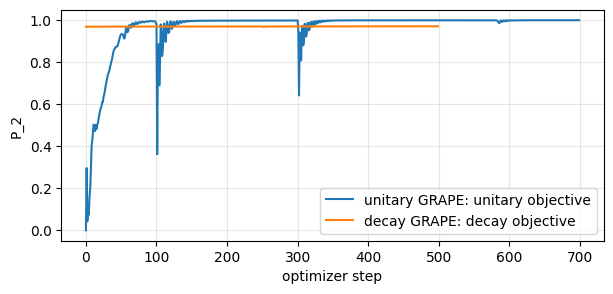

unitary pulse / unitary sim : 0.99972900
unitary pulse / decay sim   : 0.96913857
decay pulse / unitary sim   : 0.99959115
decay pulse / decay sim     : 0.97099655


In [31]:
plt.figure(figsize=(7, 3))
plt.plot(hist_unitary, label="unitary GRAPE: unitary objective")
plt.plot(hist_decay, label="decay GRAPE: decay objective")
plt.xlabel("optimizer step")
plt.ylabel(f"P_{target_n}")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

summary = {
    "unitary pulse / unitary sim": float(unitary_probability(ctrl_unitary)),
    "unitary pulse / decay sim": float(decay_probability(ctrl_unitary)),
    "decay pulse / unitary sim": float(unitary_probability(ctrl_decay)),
    "decay pulse / decay sim": float(decay_probability(ctrl_decay)),
}
for name, value in summary.items():
    print(f"{name:28s}: {value:.8f}")


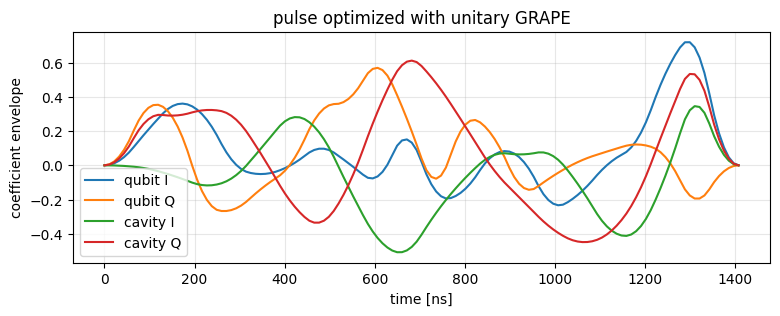

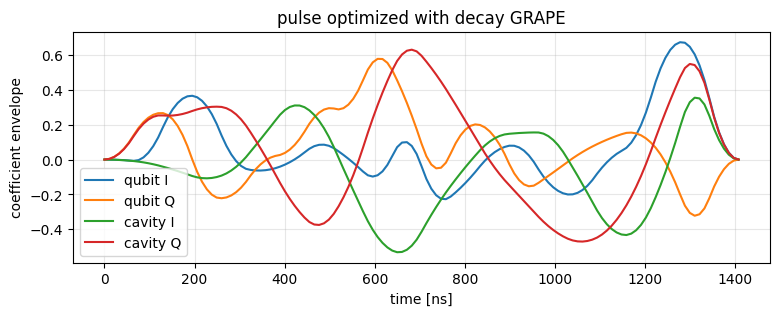

In [32]:
def plot_pulse(ctrl_coeffs, title):
    fields_edges = np.asarray(ctrl_coeffs @ bsplns_edges)
    t_ns = np.asarray(time_edges) * 1e3

    plt.figure(figsize=(9, 3))
    plt.plot(t_ns, fields_edges[0], label="qubit I")
    plt.plot(t_ns, fields_edges[1], label="qubit Q")
    plt.plot(t_ns, fields_edges[2], label="cavity I")
    plt.plot(t_ns, fields_edges[3], label="cavity Q")
    plt.xlabel("time [ns]")
    plt.ylabel("coefficient envelope")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_pulse(ctrl_unitary, "pulse optimized with unitary GRAPE")
plot_pulse(ctrl_decay, "pulse optimized with decay GRAPE")


## Dynamiqs `mesolve` double check

This is an independent open-system simulation, similar to the check in your older notebook. It evaluates the optimized B-spline pulse on a 4 ns grid, constructs `dq.pwc(...)` Hamiltonian terms, and runs `dq.mesolve` with the same T1/T2 jump operators.

This cell requires `dynamiqs` in the environment. I did not add pulse saving here.


In [33]:
import dynamiqs as dq

# Dense 4 ns grid for the independent mesolve check.
dt_check_ns = 4
T_ns = int(round(T_us * 1000))
t_edges_check_us = jnp.arange(0, T_ns + dt_check_ns, dt_check_ns) / 1000.0
t_mids_check_us = 0.5 * (t_edges_check_us[1:] + t_edges_check_us[:-1])
bsplns_check = jnp.asarray(bspline_builder(np.asarray(t_mids_check_us)))

Iq = dq.eye(2)
Ic = dq.eye(N_cav)
a_q = dq.tensor(dq.destroy(2), Ic)
a_c = dq.tensor(Iq, dq.destroy(N_cav))
a_q_dag = dq.dag(a_q)
a_c_dag = dq.dag(a_c)
n_q = a_q_dag @ a_q
n_c = a_c_dag @ a_c

H0_dq = chi * (n_c @ n_q) + 0.5 * cavity_self_kerr * (a_c_dag @ a_c_dag @ a_c @ a_c)

H_qub_I = mu_qub * (a_q + a_q_dag)
H_qub_Q = mu_qub * (1j * a_q - 1j * a_q_dag)
H_cav_I = mu_cav * (1j * a_c_dag - 1j * a_c)
H_cav_Q = mu_cav * (a_c_dag + a_c)

jump_ops_dq = [
    jnp.sqrt(1.0 / qubit_T1_us) * a_q,
    jnp.sqrt(2.0 * gamma_phi_qub) * n_q,
    jnp.sqrt(1.0 / cavity_T1_us) * a_c,
    jnp.sqrt(2.0 * gamma_phi_cav) * n_c,
]

psi0_dq = dq.tensor(dq.basis(2, 0), dq.basis(N_cav, 0))
rho0_dq = dq.todm(psi0_dq)
projector_n = dq.tensor(Iq, dq.todm(dq.basis(N_cav, target_n)))

method = dq.method.Tsit5(rtol=1e-8, atol=1e-10, max_steps=1_000_000)
options = dq.Options(save_states=True, progress_meter=True)


def dynamiqs_check(ctrl_coeffs, label):
    fields = jnp.asarray(ctrl_coeffs @ bsplns_check)
    eps_qub_I = fields[0]
    eps_qub_Q = fields[1]
    eps_cav_I = fields[2]
    eps_cav_Q = fields[3]

    H_t = (
        H0_dq
        + dq.pwc(t_edges_check_us, eps_qub_I, H_qub_I)
        + dq.pwc(t_edges_check_us, eps_qub_Q, H_qub_Q)
        + dq.pwc(t_edges_check_us, eps_cav_I, H_cav_I)
        + dq.pwc(t_edges_check_us, eps_cav_Q, H_cav_Q)
    )

    result = dq.mesolve(
        H=H_t,
        jump_ops=jump_ops_dq,
        rho0=rho0_dq,
        tsave=t_edges_check_us,
        exp_ops=[projector_n],
        method=method,
        options=options,
    )
    rho_final = result.states[-1]
    p_n = float(jnp.real(dq.expect(projector_n, rho_final)))
    print(f"{label}: dynamiqs mesolve P_{target_n} = {p_n:.8f}")
    return p_n, result

p_unitary_dq, result_unitary_dq = dynamiqs_check(ctrl_unitary, "unitary-GRAPE pulse")
p_decay_dq, result_decay_dq = dynamiqs_check(ctrl_decay, "decay-GRAPE pulse")


|██████████| 100.0% ◆ elapsed 231.19ms ◆ remaining 0.00ms 


unitary-GRAPE pulse: dynamiqs mesolve P_2 = 0.96620206


|██████████| 100.0% ◆ elapsed 227.98ms ◆ remaining 0.00ms 

decay-GRAPE pulse: dynamiqs mesolve P_2 = 0.96759321
